In [56]:
import kagglehub

path = kagglehub.dataset_download("sharmajicoder/amazon-e-commerce")
print(path)

Using Colab cache for faster access to the 'amazon-e-commerce' dataset.
/kaggle/input/amazon-e-commerce


In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [58]:
import os

csv_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

df = pd.read_csv(csv_files[0])
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


In [59]:
# Inspect
df.info()

# Missing values
df.isnull().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix datatypes
df["purchase_date"] = pd.to_datetime(df["purchase_date"])

# Feature engineering
df["month"] = df["purchase_date"].dt.month_name()
df["year"] = df["purchase_date"].dt.year


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1000000 non-null  object 
 1   product_id          1000000 non-null  object 
 2   category            1000000 non-null  object 
 3   subcategory         1000000 non-null  object 
 4   brand               1000000 non-null  object 
 5   price               1000000 non-null  float64
 6   discount            1000000 non-null  float64
 7   final_price         1000000 non-null  float64
 8   rating              1000000 non-null  float64
 9   review_count        1000000 non-null  int64  
 10  stock               1000000 non-null  int64  
 11  seller_id           1000000 non-null  object 
 12  seller_rating       1000000 non-null  float64
 13  purchase_date       1000000 non-null  object 
 14  shipping_time_days  1000000 non-null  int64  
 15  location        

In [60]:
total_revenue = df["final_price"].sum()
print("Total Revenue:", total_revenue)

total_orders = df.shape[0]
print("Total Orders:", total_orders)

total_customers = df["user_id"].nunique()
print("Total Customers:", total_customers)

total_products = df["product_id"].nunique()
print("Total Products:", total_products)

aov = df["final_price"].sum() / df.shape[0]
print("Average Order Value:", aov)

return_rate = df["is_returned"].mean() * 100
print("Return Rate %:", return_rate)

avg_discount = df["discount"].mean()
print("Average Discount:", avg_discount)

avg_rating = df["rating"].mean()
print("Average Rating:", avg_rating)

Total Revenue: 9938876984.9
Total Orders: 1000000
Total Customers: 603815
Total Products: 89999
Average Order Value: 9938.8769849
Return Rate %: 11.599
Average Discount: 28.996160609999986
Average Rating: 3.9272262


In [61]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12,6)

os.makedirs("images", exist_ok=True)

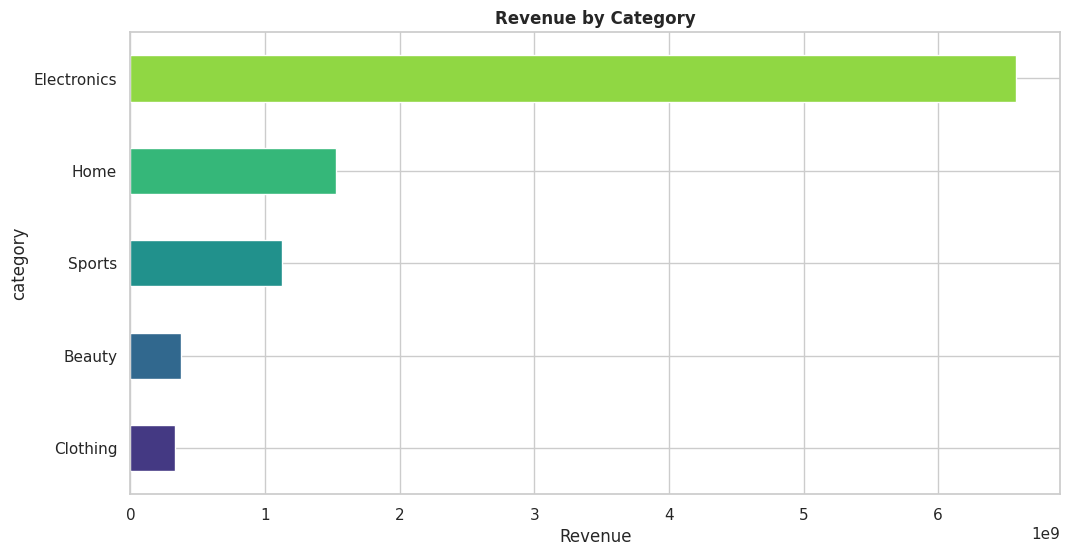

In [62]:
data = df.groupby("category")["final_price"].sum().sort_values()

plt.figure()
data.plot(kind="barh", color=sns.color_palette("viridis", len(data)))

plt.title("Revenue by Category")
plt.xlabel("Revenue")

plt.savefig("images/revenue_by_category.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_752/2697650394.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette="rocket")


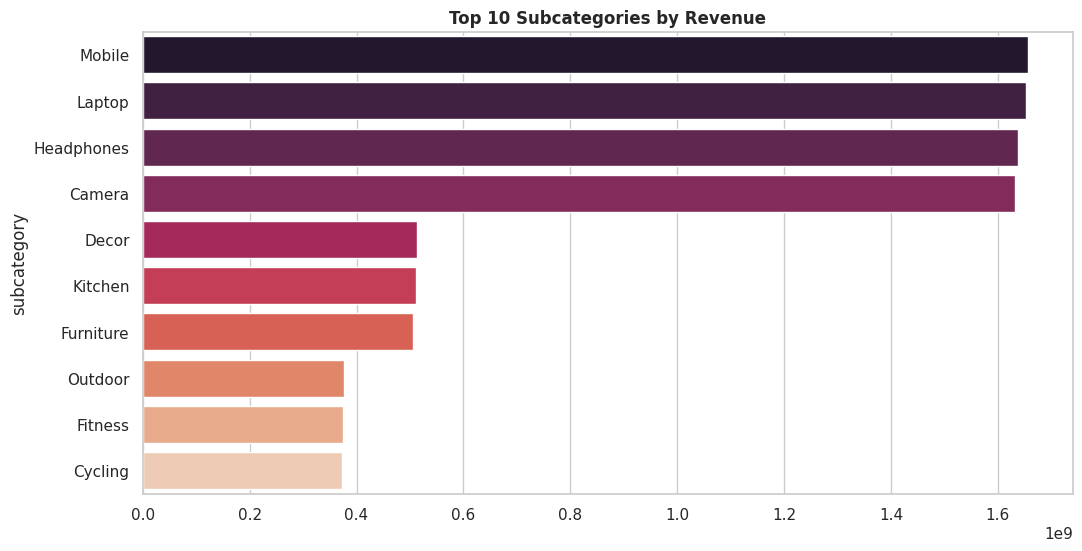

In [63]:
data = df.groupby("subcategory")["final_price"].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=data.values, y=data.index, palette="rocket")

plt.title("Top 10 Subcategories by Revenue")

plt.savefig("images/top_subcategories.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_752/14792719.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette="mako")


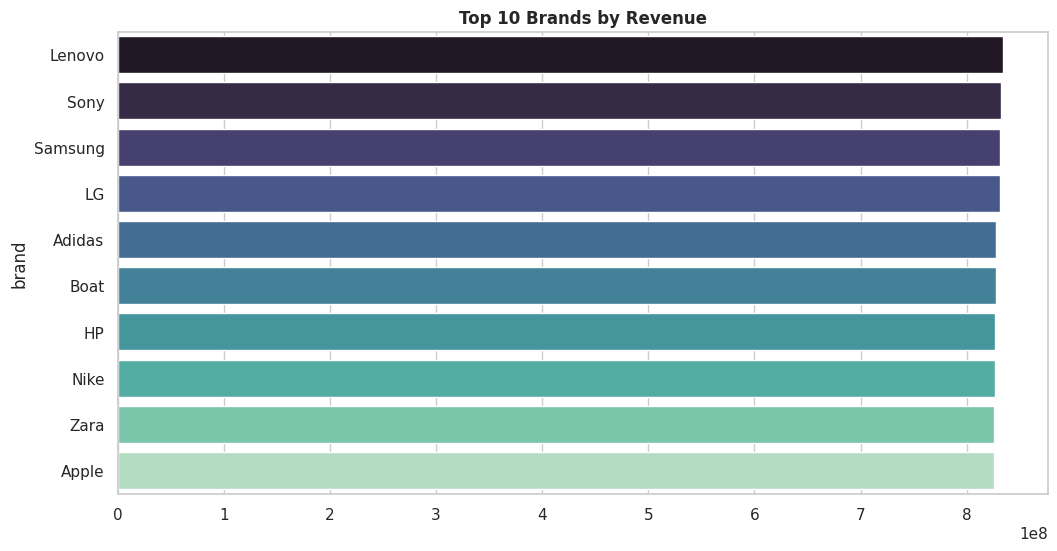

In [64]:
data = df.groupby("brand")["final_price"].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=data.values, y=data.index, palette="mako")

plt.title("Top 10 Brands by Revenue")

plt.savefig("images/top_brands.png", bbox_inches="tight")
plt.show()

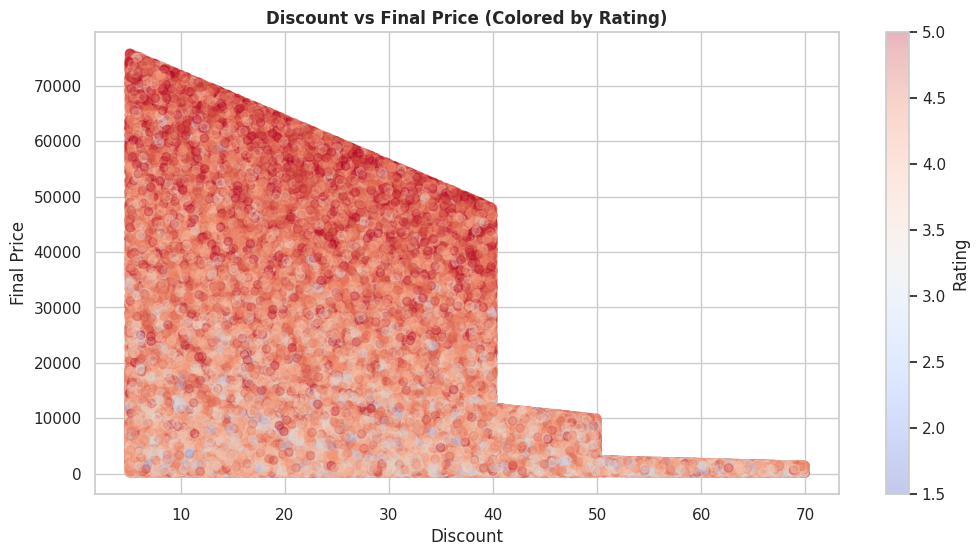

In [76]:
plt.scatter(df["discount"], df["final_price"], alpha=0.3, c=df["rating"], cmap="coolwarm")

plt.title("Discount vs Final Price (Colored by Rating)")
plt.xlabel("Discount")
plt.ylabel("Final Price")

plt.colorbar(label="Rating")

plt.savefig("images/price_vs_final_price.png", bbox_inches="tight")
plt.show()

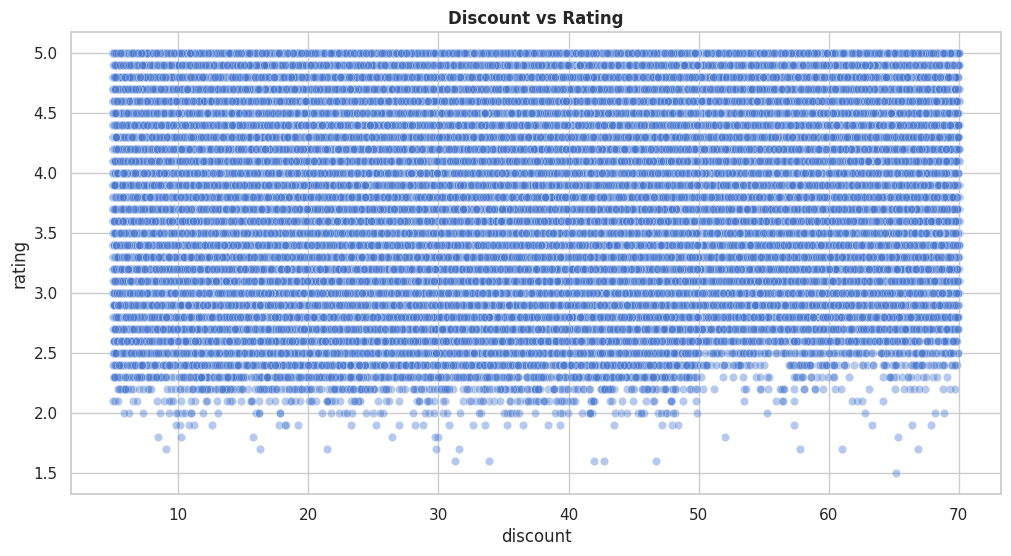

In [66]:
plt.figure()

sns.scatterplot(data=df, x="discount", y="rating", alpha=0.4)

plt.title("Discount vs Rating")

plt.savefig("images/discount_vs_rating.png", bbox_inches="tight")
plt.show()

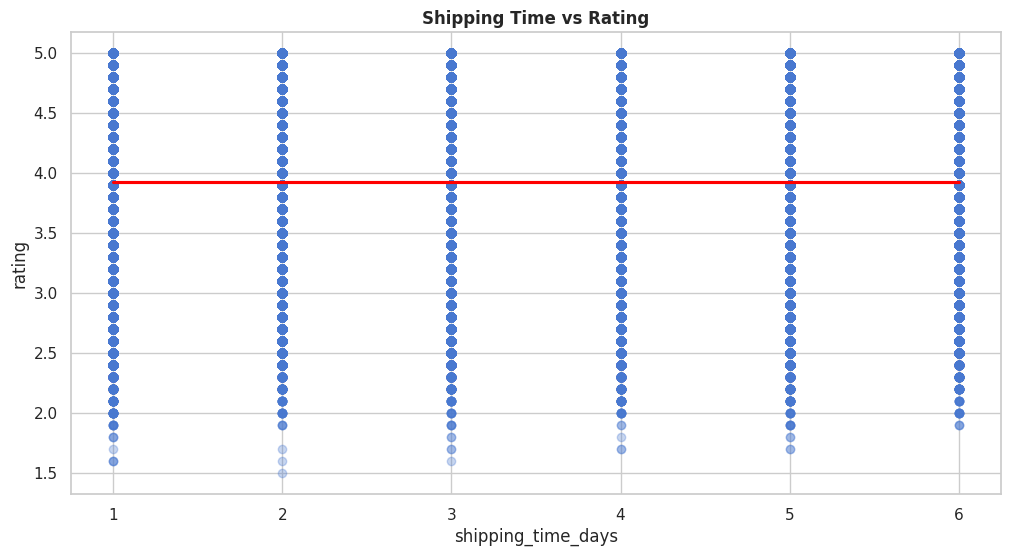

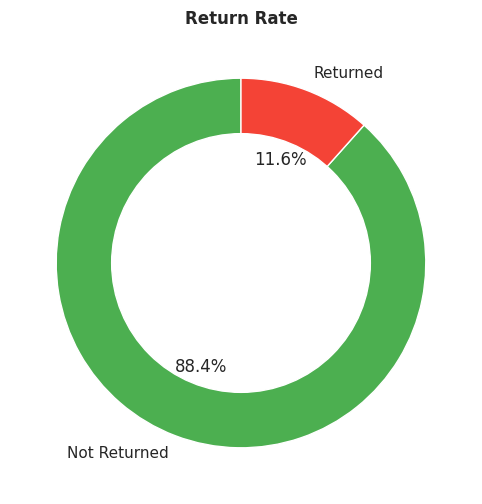

In [68]:
returns = df["is_returned"].value_counts()

plt.figure()

plt.pie(
    returns,
    labels=["Not Returned", "Returned"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#F44336"]
)

centre = plt.Circle((0,0),0.70,fc="white")
plt.gca().add_artist(centre)

plt.title("Return Rate")

plt.savefig("images/return_rate.png", bbox_inches="tight")
plt.show()

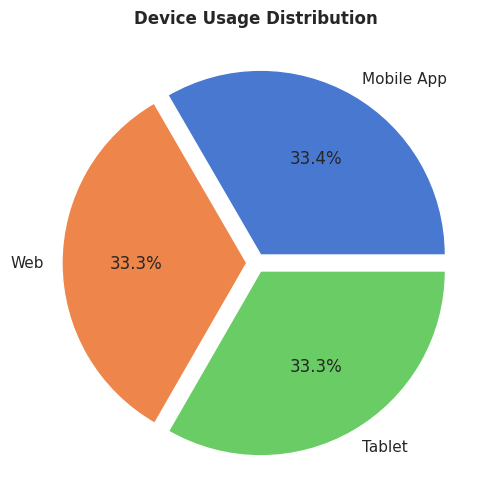

In [69]:
data = df["device"].value_counts()

plt.figure()
plt.pie(data, labels=data.index, autopct="%1.1f%%", explode=[0.05]*len(data))

plt.title("Device Usage Distribution")

plt.savefig("images/device_usage.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_752/2300777668.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette="viridis")


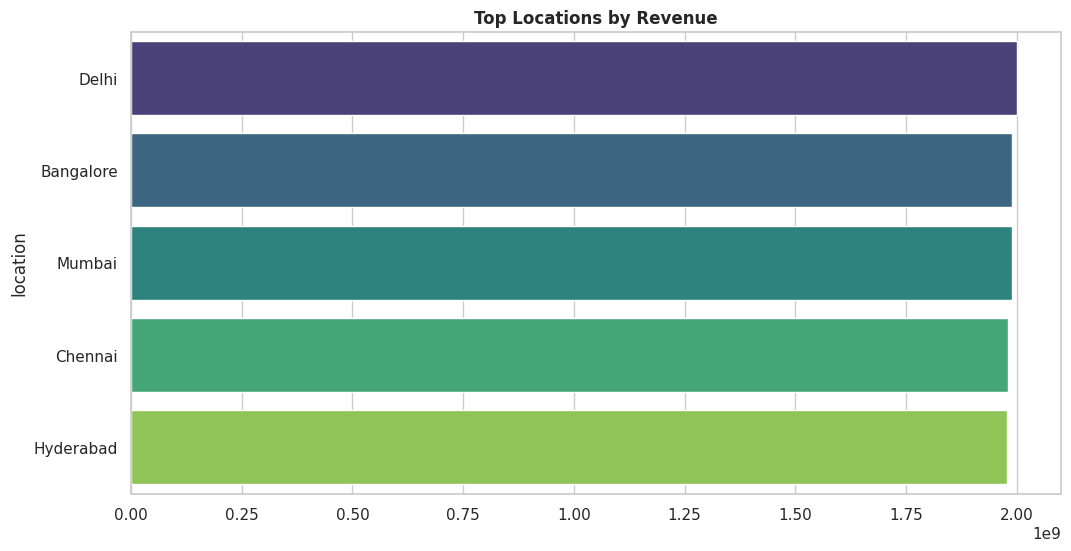

In [70]:
data = df.groupby("location")["final_price"].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=data.values, y=data.index, palette="viridis")

plt.title("Top Locations by Revenue")

plt.savefig("images/location_revenue.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_752/1745779276.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette="cubehelix")


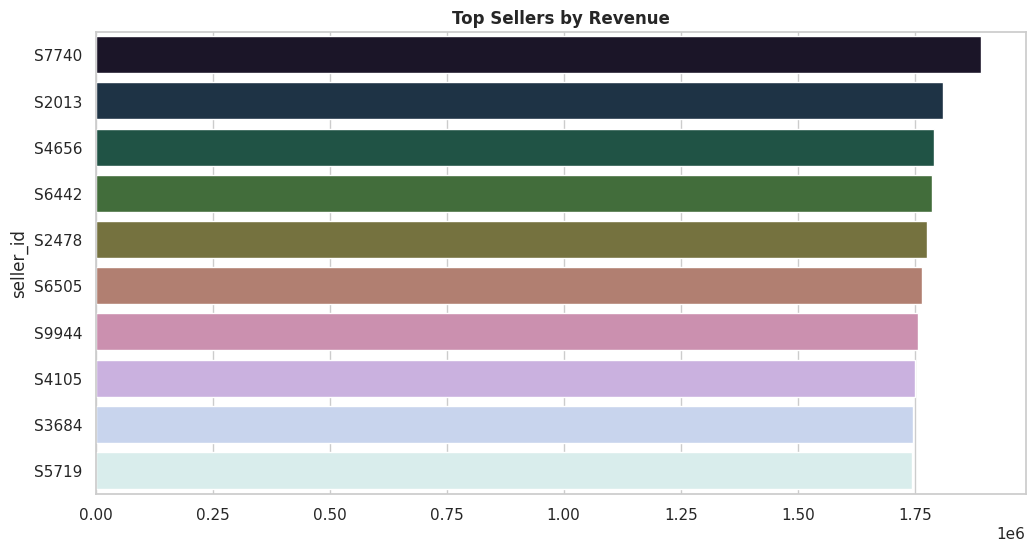

In [71]:
data = df.groupby("seller_id")["final_price"].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=data.values, y=data.index, palette="cubehelix")

plt.title("Top Sellers by Revenue")

plt.savefig("images/seller_performance.png", bbox_inches="tight")
plt.show()

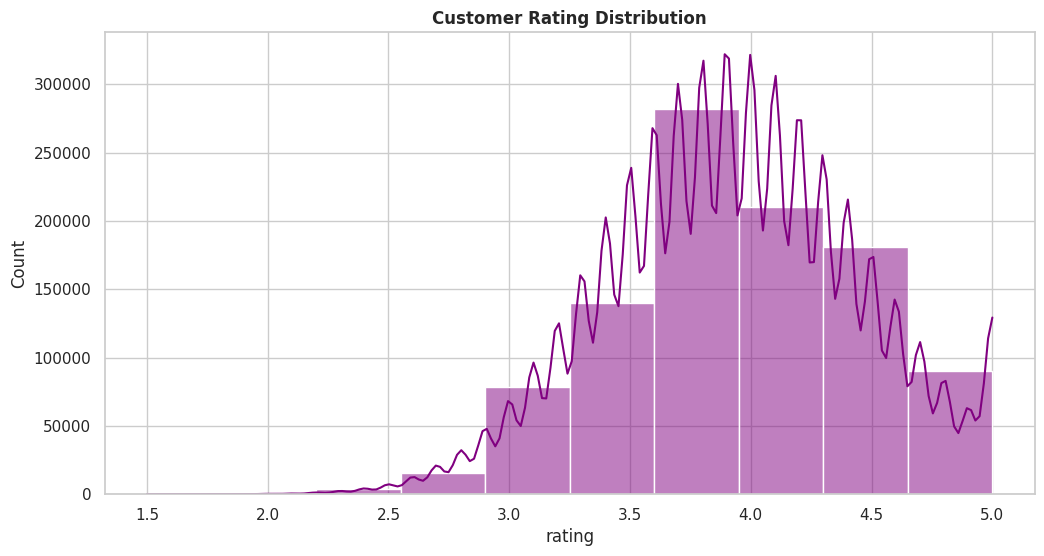

In [72]:
plt.figure()

sns.histplot(df["rating"], bins=10, kde=True, color="purple")

plt.title("Customer Rating Distribution")

plt.savefig("images/rating_distribution.png", bbox_inches="tight")
plt.show()

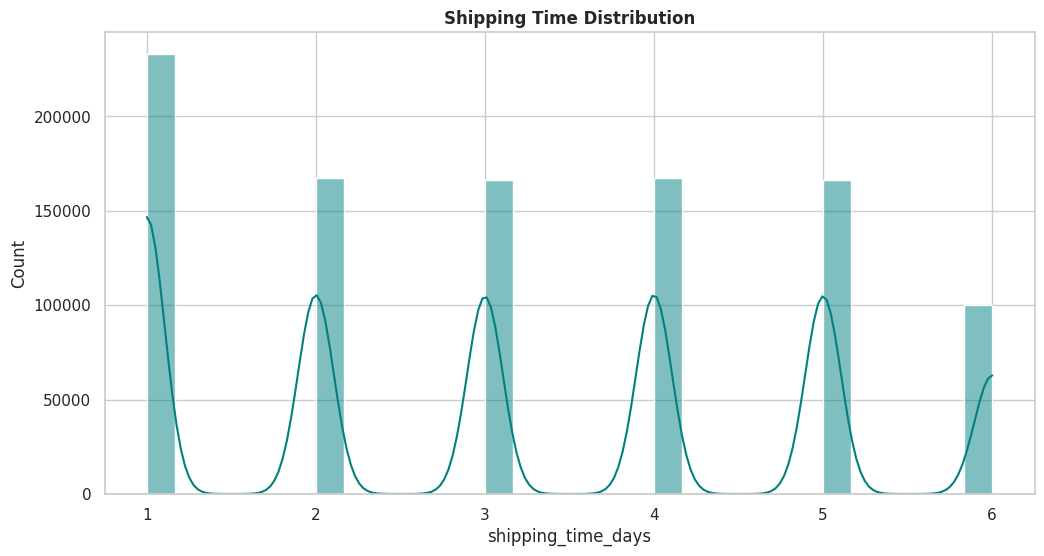

In [73]:
plt.figure()

sns.histplot(df["shipping_time_days"], bins=30, kde=True, color="teal")

plt.title("Shipping Time Distribution")

plt.savefig("images/shipping_distribution.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_752/1549278378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="category", y="rating", data=df, palette="Set3")


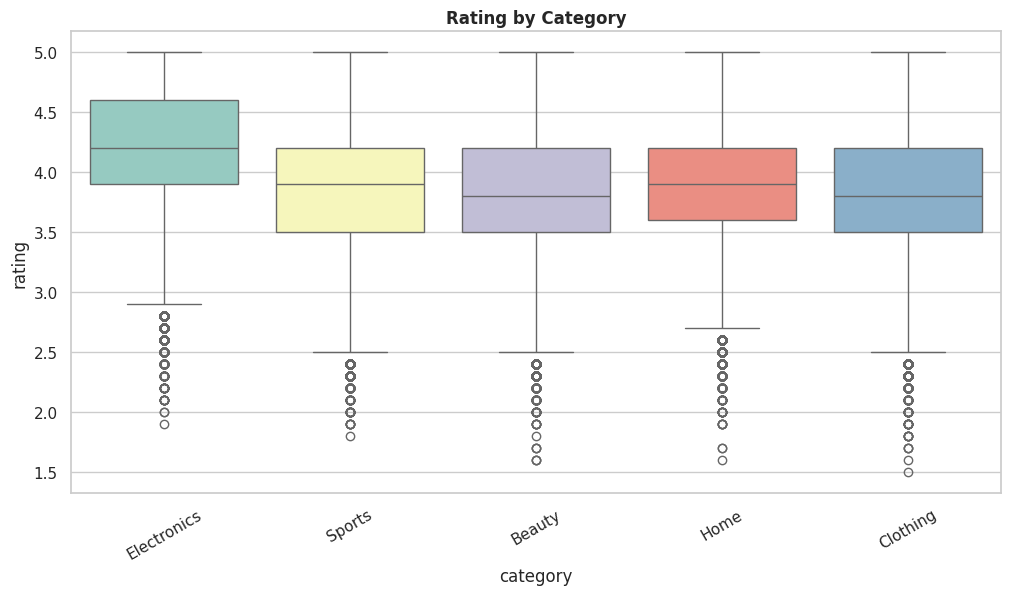

In [74]:
plt.figure()

sns.boxplot(x="category", y="rating", data=df, palette="Set3")

plt.title("Rating by Category")

plt.xticks(rotation=30)

plt.savefig("images/category_rating.png", bbox_inches="tight")
plt.show()

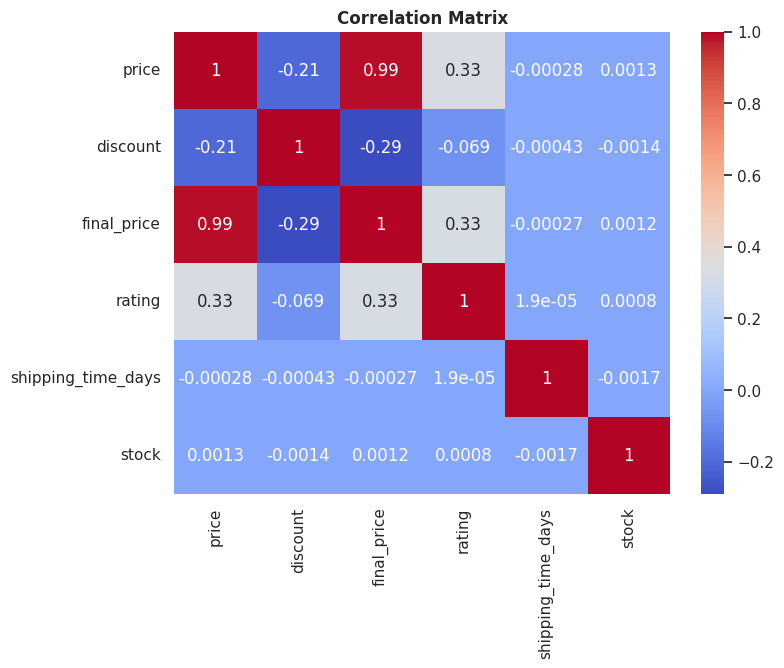

In [75]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["price","discount","final_price","rating","shipping_time_days","stock"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig("images/correlation_matrix.png", bbox_inches="tight")
plt.show()